In [1]:
# Importiing libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer

In [2]:
# Loading the dataset
df = pd.read_csv(r"C:\Users\User\Desktop\Medical_Insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
# formatting the dataset to 2 decimals
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [4]:
# checking for nulls or missing information
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [5]:
(df.isnull().sum() / len(df)) * 100

age        0.00
sex        0.00
bmi        0.00
children   0.00
smoker     0.00
region     0.00
charges    0.00
dtype: float64

In [6]:
# diplaying of the data types in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
# formatting the dataset to 2 decimals
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [8]:
# checking for nulls or missing information
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [9]:
# checking for unique values
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

In [10]:
# statistic calculations
df.describe()

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


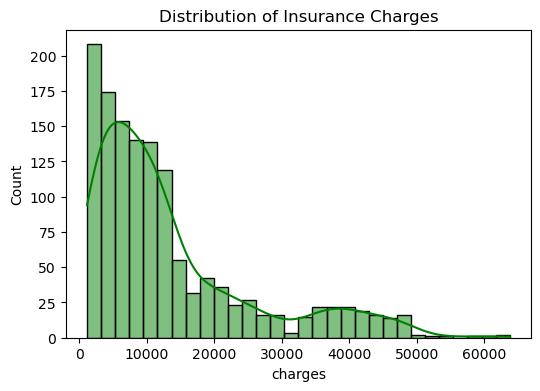

In [14]:
import seaborn as sns
# histogram between charges and number of clients per charge
plt.figure(figsize=(6, 4))
sns.histplot(df['charges'], kde=True, color='green')
plt.title('Distribution of Insurance Charges')
plt.show()

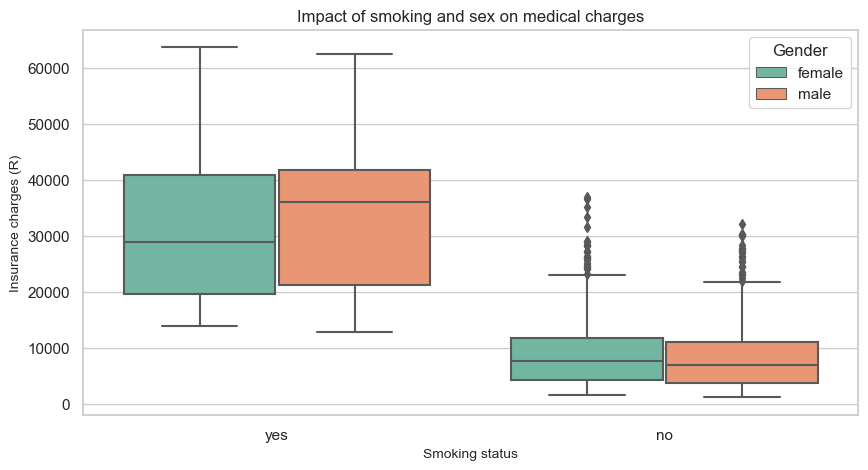

In [15]:
# Setting a clear visual style which is a whitegrid
sns.set_theme(style="whitegrid")

# Creating the boxplot and defining the size of the graph
# The x-axis sums up the smokers and those who do not smoke
# The y-axis shows roughly the amount of charges of the smokers and non-smokers distribution
# the hue group sex (male and female)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='smoker', y='charges', hue='sex', palette='Set2')

# Customise labels for readability
plt.title('Impact of smoking and sex on medical charges', fontsize=12)
plt.xlabel('Smoking status', fontsize=10)
plt.ylabel('Insurance charges (R)', fontsize=10)
plt.legend(title='Gender')

# Showing the plot graph
plt.show()

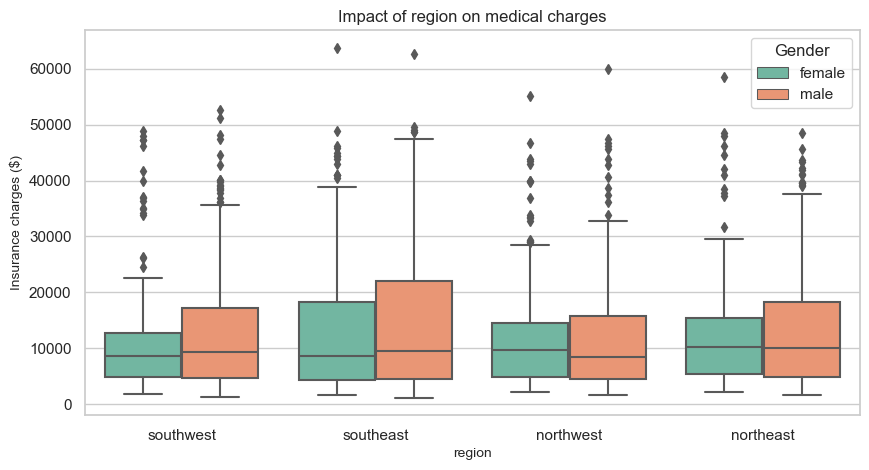

In [16]:
# Setting a clear visual style which is a whitegrid
sns.set_theme(style="whitegrid")

# Creating the boxplot and defining the size of the graph
# The x-axis shows the charges
# The y-axis shows the regions
# the hue group sex (male and female)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='region', y='charges', hue='sex', palette='Set2')

# Customise labels for readability
plt.title('Impact of region on medical charges', fontsize=12)
plt.xlabel('region', fontsize=10)
plt.ylabel('Insurance charges ($)', fontsize=10)
plt.legend(title='Gender')

# Showing the plot graph
plt.show()

<AxesSubplot:xlabel='age', ylabel='charges'>

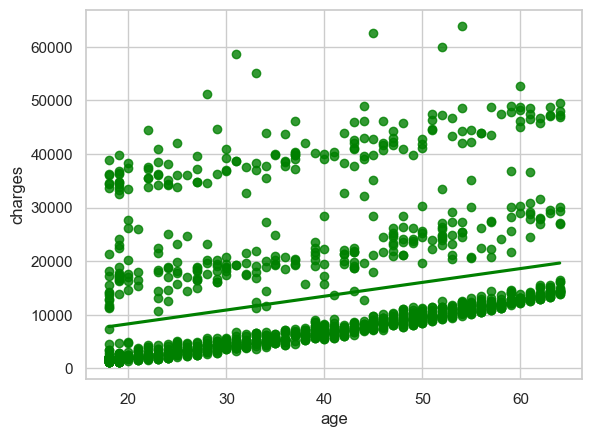

In [18]:
# using regplot
import seaborn as sb

sb.regplot(x = "age",
            y = "charges", 
            ci = None,
            color='green',
            data = df)

In [20]:
# removing outlier on charges that are 50000 and above

# Only values that are less than 50000 will remain
df = df[df['charges'] <= 50000]


In [21]:
df.shape

(1331, 7)

In [45]:
# Converting the variables to dummy variables
df_encoded = pd.get_dummies(df, drop_first=True)

# printing the results
print(df_encoded.head())

   age   bmi  children  charges  sex_male  smoker_yes  region_northwest  \
0   19 27.90         0 16884.92         0           1                 0   
1   18 33.77         1  1725.55         1           0                 0   
2   28 33.00         3  4449.46         1           0                 0   
3   33 22.70         0 21984.47         1           0                 1   
4   32 28.88         0  3866.86         1           0                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  


In [49]:
from sklearn.model_selection import train_test_split
# Assumption: 'df_encoded' the DataFrame after converting categories to numbers

# Defining the Features (X)
# Dropping 'charges' so that the model doesn't see answers in advance
X = df_encoded.drop(columns=['charges'])

# Defining the Target Variable (y)
y = df_encoded['charges']

# Verifying the shapes
print(f"Features shape: {X.shape}") # showing all colunms except the 'charges'
print(f"Target shape: {y.shape}")     # showing only one column 

Features shape: (1331, 8)
Target shape: (1331,)


In [53]:
# checking encode results
print(df_encoded.columns)

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')


In [61]:
X = df_encoded.drop(columns=['charges'])
y = df_encoded['charges']

In [64]:
# importing train_test_split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [65]:
# Trainining the model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [66]:
# making a prediction
y_pred = model.predict(X_test)
print(y_pred[:9])

[ 9479.18134573  9684.36431265  7442.89004601 31789.55960417
  6830.40763236  4264.05398226  5957.33237021  9266.22874225
 12133.92502215]


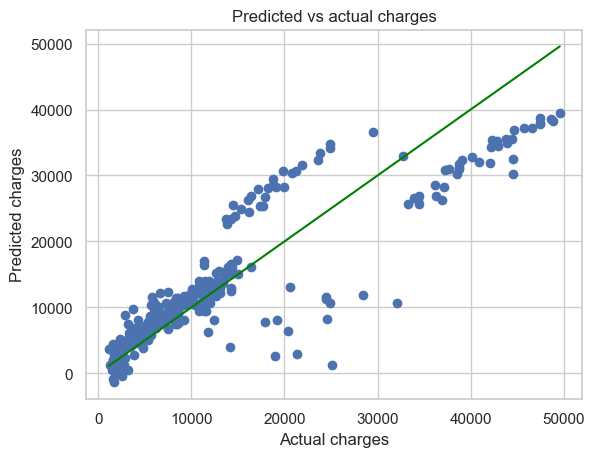

In [68]:
# plotting scatter graph showing predicted charges versus actual charges
plt.scatter(y_test, y_pred)
plt.xlabel("Actual charges")
plt.ylabel("Predicted charges")
plt.title("Predicted vs actual charges")

# prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='green')

plt.show()

In [69]:
# importing scikit-learn metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# evaluating the model with scikit-learn metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean absolute error:", mae)
print("mean squared error:", mse)
print("root mean squared error:", rmse)
print("R-squared score:", r2)

Mean absolute error: 4226.40971225337
mean squared error: 35673232.89658567
root mean squared error: 5972.707333913631
R-squared score: 0.7753095020969256
